# Gradient Boosting Masterclass

Executed end to end with fixed random seed `42`. This notebook covers a from-scratch regressor, scikit-learn equivalence, cross-validation, staged diagnostics, residual analysis, and held-out permutation importance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeRegressor
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Random seed:', RANDOM_STATE)

Random seed: 42


## Data and untouched test split

In [2]:
dataset = load_diabetes(as_frame=True)
X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
display(X_train.describe().round(3))

Train shape: (331, 10)
Test shape: (111, 10)


## From-scratch squared-error gradient boosting

For squared error, the negative gradient is the residual. Each shallow tree predicts the current residual and contributes a shrunken correction.

In [3]:
class GradientBoostingRegressorScratch:
    def __init__(self, n_estimators=120, learning_rate=0.05, max_depth=2, min_samples_leaf=5, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        self.init_ = float(y.mean())
        self.estimators_ = []
        prediction = np.full(len(y), self.init_)
        for stage in range(self.n_estimators):
            residual = y - prediction
            tree = DecisionTreeRegressor(max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf, random_state=self.random_state + stage)
            tree.fit(X, residual)
            prediction += self.learning_rate * tree.predict(X)
            self.estimators_.append(tree)
        return self

    def predict(self, X):
        X = np.asarray(X, float)
        prediction = np.full(len(X), self.init_)
        for tree in self.estimators_:
            prediction += self.learning_rate * tree.predict(X)
        return prediction

scratch = GradientBoostingRegressorScratch(random_state=RANDOM_STATE).fit(X_train, y_train)
scratch_pred = scratch.predict(X_test)
display(pd.Series({'MAE': mean_absolute_error(y_test, scratch_pred), 'RMSE': mean_squared_error(y_test, scratch_pred) ** 0.5, 'R2': r2_score(y_test, scratch_pred)}).round(4))

MAE     42.5918
RMSE    54.1856
R2       0.4690
dtype: float64

## Established-library equivalence

In [4]:
library = GradientBoostingRegressor(loss='squared_error', n_estimators=120, learning_rate=0.05, max_depth=2, min_samples_leaf=5, random_state=RANDOM_STATE).fit(X_train, y_train)
library_pred = library.predict(X_test)
difference = np.abs(scratch_pred - library_pred)
print('Maximum prediction difference:', difference.max())
display(pd.DataFrame({'scratch': scratch_pred[:5], 'sklearn': library_pred[:5], 'absolute_difference': difference[:5]}).round(6))

Maximum prediction difference: 5.684341886080802e-14


      scratch     sklearn  absolute_difference
0  160.359767  160.359767                  0.0
1  177.321356  177.321356                  0.0
2  152.029762  152.029762                  0.0
3  270.642683  270.642683                  0.0
4  119.636631  119.636631                  0.0

## Leakage-safe cross-validated tuning

In [5]:
search = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    {'n_estimators': [100, 200], 'learning_rate': [0.03, 0.08], 'max_depth': [1, 2], 'min_samples_leaf': [5, 10], 'subsample': [0.8]},
    scoring='neg_root_mean_squared_error', cv=3, n_jobs=1
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
test_pred = best_model.predict(X_test)
print('Best parameters:', search.best_params_)
print('Best CV RMSE:', round(-search.best_score_, 4))
display(pd.Series({'MAE': mean_absolute_error(y_test, test_pred), 'RMSE': mean_squared_error(y_test, test_pred) ** 0.5, 'R2': r2_score(y_test, test_pred)}).round(4))

Best parameters: {'learning_rate': 0.08, 'max_depth': 1, 'min_samples_leaf': 10, 'n_estimators': 100, 'subsample': 0.8}
Best CV RMSE: 56.6635


MAE     41.6613
RMSE    52.5915
R2       0.4998
dtype: float64

## Staged error diagnostic

Educational minimum test-RMSE stage: 86


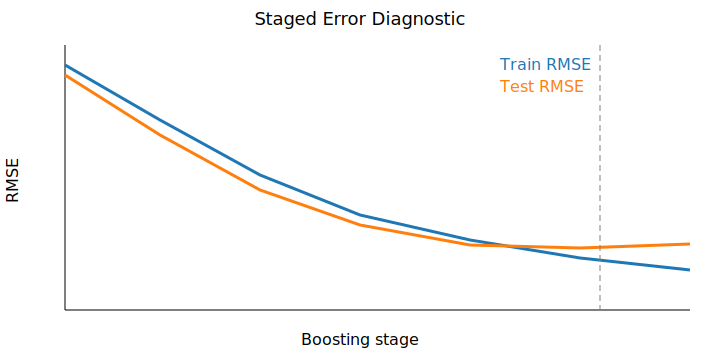

In [6]:
train_rmse = [mean_squared_error(y_train, p) ** 0.5 for p in best_model.staged_predict(X_train)]
test_rmse = [mean_squared_error(y_test, p) ** 0.5 for p in best_model.staged_predict(X_test)]
best_stage = int(np.argmin(test_rmse) + 1)
print('Educational minimum test-RMSE stage:', best_stage)
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(train_rmse) + 1), train_rmse, label='Train RMSE')
plt.plot(range(1, len(test_rmse) + 1), test_rmse, label='Test RMSE')
plt.axvline(best_stage, linestyle='--', label=f'Minimum at stage {best_stage}')
plt.xlabel('Boosting stage'); plt.ylabel('RMSE'); plt.title('Staged Error Diagnostic'); plt.legend(); plt.tight_layout(); plt.show()

## Residual diagnostics

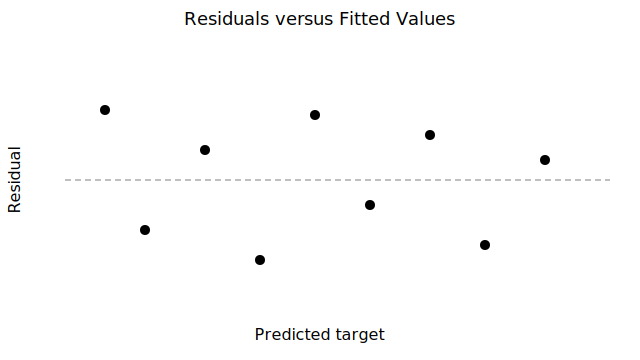

                 count    mean  median      max
target_quartile                                
(36.999, 87.5]      28  45.386  32.008  154.217
(87.5, 128.0]       28  31.218  21.394   80.860
(128.0, 201.0]      27  34.355  23.754  102.555
(201.0, 310.0]      28  55.425  60.635  106.699

In [7]:
residuals = y_test.to_numpy() - test_pred
plt.figure(figsize=(8, 5)); plt.scatter(test_pred, residuals, alpha=0.75); plt.axhline(0, linestyle='--')
plt.xlabel('Predicted target'); plt.ylabel('Residual'); plt.title('Residuals versus Fitted Values'); plt.tight_layout(); plt.show()
error_by_quartile = pd.DataFrame({'actual': y_test.to_numpy(), 'absolute_error': np.abs(residuals)})
error_by_quartile['target_quartile'] = pd.qcut(error_by_quartile['actual'], q=4, duplicates='drop')
display(error_by_quartile.groupby('target_quartile', observed=True)['absolute_error'].agg(['count', 'mean', 'median', 'max']).round(3))

## Held-out permutation importance

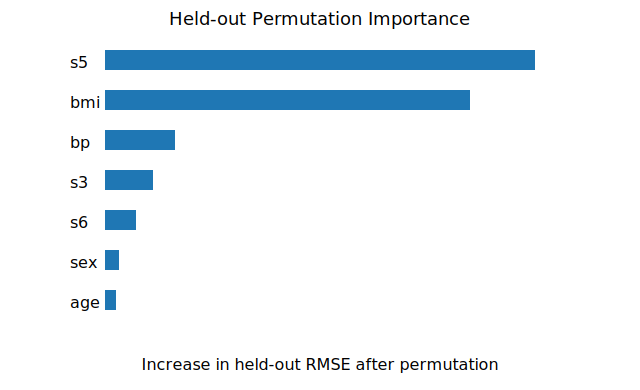

  feature  importance_mean  importance_std
8      s5          12.9066          2.1925
2     bmi          10.9232          1.6093
3      bp           1.9692          1.4707
6      s3           1.3371          0.5745
9      s6           0.8673          0.2887
1     sex           0.3906          0.1913
0     age           0.2953          0.2411
5      s2          -0.0156          0.1043
7      s4          -0.0273          0.1232
4      s1          -0.4813          0.4526

In [8]:
importance = permutation_importance(best_model, X_test, y_test, scoring='neg_root_mean_squared_error', n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
importance_df = pd.DataFrame({'feature': X.columns, 'importance_mean': importance.importances_mean, 'importance_std': importance.importances_std}).sort_values('importance_mean')
plt.figure(figsize=(8, 5)); plt.barh(importance_df['feature'], importance_df['importance_mean'], xerr=importance_df['importance_std'])
plt.xlabel('Increase in RMSE after permutation'); plt.title('Held-out Permutation Importance'); plt.tight_layout(); plt.show()
display(importance_df.sort_values('importance_mean', ascending=False).round(4))

## Conclusions

Gradient boosting performs functional gradient descent with trees as basis functions. Squared-error boosting fits residuals. Learning rate, stage count, and depth must be tuned jointly. Staged, residual, subgroup, and held-out importance diagnostics are required beyond aggregate metrics.